# Import files <br>
**KNMI** one .npy file  & corresponding .h5 file <br> **MSG CPP** one clipped-nc file & one original-nc file









In [41]:
# !pip install rioxarray

In [42]:
# !pip install cartopy
import cartopy.feature as cfeature

In [70]:
import xarray as xr
import rioxarray
import h5py
from pathlib import Path
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pyproj import CRS, Transformer

from google.colab import drive
drive.mount('/content/drive')

ds_sub = xr.open_dataset("/content/drive/My Drive/process nc files/2020_SEVIR_OPER_R__CPP_AODC_L2__20200101T000000_20200101T001500_0002_subset.nc")
ds = xr.open_dataset("/content/drive/My Drive/process nc files/SEVIR_OPER_R__CPP_AODC_L2__20260207T081500_20260207T083000_0002.nc")
ds_h5=Path(r"/content/drive/MyDrive/process nc files/RAD_NL25_RAC_RT_202305080600.h5")
npy_path=Path(r"/content/drive/MyDrive/process nc files/202305080600.npy")

# print(ds_sub.data_vars)
ds_sub['projection']=ds['projection']
# print(ds_sub.data_vars)
ds_sub['projection'].attrs
# print(ds_sub.data_vars)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


{'grid_mapping_name': 'GEOnavigation',
 'EPSG_code': 'none',
 'long_name': 'Projection information',
 'proj4_params': '+proj=geos +a=6378.169 +b=6356.584 +h=35785.832 +lat_0=0 +lon_0=0.000000',
 'height_from_earth_center': np.float32(42164000.0),
 'latitude_of_projection_origin': np.float32(0.0),
 'longitude_of_projection_origin': np.float32(0.0),
 'scale_x': np.float32(35785.832),
 'scale_y': np.float32(-35785.832),
 'semi_major_axis': np.float32(6356584.0),
 'semi_minor_axis': np.float32(6378169.0)}

In [44]:
ds = xr.open_dataset("/content/drive/My Drive/process nc files/SEVIR_OPER_R__CPP_AODC_L2__20260207T081500_20260207T083000_0002.nc",decode_times=None)

print(f"Number of images/frames: {len(ds['time'])}")


Number of images/frames: 1


In [45]:
# ds_sub["x"]

## Ignore

In [46]:
# ds.data_vars
# ds_sub.coords.to_dataset()  ##contains x and y
# ds_sub.variables

# ##TRY 1
# ds_sub_grid_mapping = ds_sub['ctt'].attrs.get('grid mapping')
# print(ds_sub_grid_mapping)  ##GET NONE

# ##TRY 2
# # ds_sub_grid_mapping = ds_sub['ctt'].encoding.get('grid mapping')
# # print(ds_sub_grid_mapping)  ##GET NONE

# ##TRY 3
# for v in ds_sub.data_vars:
#     if 'grid_mapping' in ds_sub[v].attrs:
#         print(v, ds_sub[v].attrs['grid_mapping'])   ##GET var+projection

# ##TRY 4
# ds_sub_grid_mapping = ds_sub['ctt'].attrs.get('projection') ##GET ERROR
# print(ds_sub_grid_mapping) ##GET ERROR
# ds['ctt'].attrs
# ds['projection']

In [47]:
##check nc file spatial resolution
float(ds_sub["x"][1] - ds_sub["x"][0]), float(ds_sub["y"][1] - ds_sub["y"][0])  #checking if the x and y interval are the same (reminder: it's the projection); checking what the interval is


(3.00048828125, -3.00048828125)

#Start


## Explore the projection in .h5 (KNMI) file

In [48]:
#@title Explore the structure of h5 file
def walk(name, obj):
    if isinstance(obj, h5py.Group):
        print(f"[G] {name}")
    else:
        print(f"[D] {name} shape={obj.shape} dtype={obj.dtype}")

with h5py.File(ds_h5, "r") as f:
    f.visititems(walk)

[G] geographic
[G] geographic/map_projection
[G] image1
[G] image1/calibration
[D] image1/image_data shape=(765, 700) dtype=uint16
[G] image1/statistics
[G] image2
[G] image2/calibration
[D] image2/image_data shape=(765, 700) dtype=uint16
[G] image2/statistics
[G] image3
[G] image3/calibration
[D] image3/image_data shape=(765, 700) dtype=uint16
[G] image3/statistics
[G] overview
[G] radar1
[G] radar2
[G] radar3
[G] radar4
[G] radar5
[G] radar6


In [49]:
#@title  Key and value of h5py

with h5py.File(ds_h5, "r") as f:
    mp = f["overview"]
    print("=== overview attrs ===") ##CRS is in here
    for k, v in mp.attrs.items(): #key (attribute name), value (attribute value)
        if isinstance(v, (bytes, bytearray)):
            v = v.decode("utf-8", errors="ignore")
        print(k, "=", v)
    image_data = f["image1/image_data"].attrs.items()
    print("\n--- Attributes for image1 ---")
    for k, v in image_data:
        if isinstance(v, (bytes, bytearray)):
            v = v.decode("utf-8", errors="ignore")
        print(f"{k} = {v}")
    radar1 = f["radar1"].attrs.items()
    print("\n--- Attributes for radar1 ---")
    for k, v in radar1:
        if isinstance(v, (bytes, bytearray)):
            v = v.decode("utf-8", errors="ignore")
        print(f"{k} = {v}")

=== overview attrs ===
hdftag_version_number = 3.6
number_image_groups = [3]
number_radar_groups = [4]
number_satellite_groups = [0]
number_scan_groups = [16]
number_station_groups = [0]
product_datetime_end = 08-MAY-2023;06:00:03.000
product_datetime_start = 08-MAY-2023;05:55:03.000
product_group_name = RAD_NL25_COR_NA
product_missing = NA

--- Attributes for image1 ---
CLASS = IMAGE
DISPLAY_ORIGIN = UL
IMAGE_VERSION = 1.2

--- Attributes for radar1 ---
radar_location = [ 4.79061 52.95279]
radar_name = Den Helder
radar_operational = [1]


In [50]:
##this part checks where CRS/lat,lon/x,y information is stored.
with h5py.File(ds_h5, "r") as f:
    mp = f["geographic/map_projection"]
    print("=== geographic/map_projection attrs ===") ##CRS is in here
    for k, v in mp.attrs.items(): #key (attribute name), value (attribute value)
        if isinstance(v, (bytes, bytearray)):
            v = v.decode("utf-8", errors="ignore")
        print(k, "=", v)
    g = f["geographic"]
    print("\n=== geographic attrs ===")         ##grid parameteres are in here

    for k, v in g.attrs.items():
        if isinstance(v, (bytes, bytearray)):
            v = v.decode("utf-8", errors="ignore")  ##LU means the center pixel is defined to be ''Left Upper''
        print(k, "=", v)


=== geographic/map_projection attrs ===
projection_indication = Y
projection_name = STEREOGRAPHIC
projection_proj4_params = +proj=stere +lat_0=90 +lon_0=0 +lat_ts=60 +a=6378.14 +b=6356.75 +x_0=0 y_0=0

=== geographic attrs ===
geo_column_offset = [0.]
geo_dim_pixel = KM,KM
geo_number_columns = [700]
geo_number_rows = [765]
geo_par_pixel = X,Y
geo_pixel_def = LU
geo_pixel_size_x = [1.0000035]
geo_pixel_size_y = [-1.0000048]
geo_product_corners = [ 0.       49.362064  0.       55.973602 10.856453 55.388973  9.0093
 48.8953  ]
geo_row_offset = [3649.982]


In [51]:
from pyproj import CRS, Transformer
import numpy as np
def clean_proj4(proj4: str) -> str:
    proj4 = proj4.replace(" y_0=", " +y_0=")
    tokens = proj4.split()
    out = []
    for t in tokens:
        if t.startswith("+a=") or t.startswith("+b="):
            k, v = t.split("=")
            vv = float(v)
            if vv < 1e7:  # km -> m
                vv *= 1000.0
            out.append(f"{k}={vv}")
        else:
            out.append(t)
    if not any(tok.startswith("+units=") for tok in out):
        out.append("+units=m")
    if "+no_defs" not in out:
        out.append("+no_defs")
    return " ".join(out)

def order_corners_xy(X, Y):
    pts = np.stack([X, Y], axis=1)

    # top two: largest Y
    idx_sorted_by_y = np.argsort(pts[:,1])  # ascending
    top2 = idx_sorted_by_y[-2:]
    bot2 = idx_sorted_by_y[:2]

    # among top2, left has smaller X
    top2 = top2[np.argsort(pts[top2,0])]
    UL, UR = top2[0], top2[1]

    # among bot2, left has smaller X
    bot2 = bot2[np.argsort(pts[bot2,0])]
    LL, LR = bot2[0], bot2[1]

    return UL, UR, LR, LL

def make_xy_from_corners_robust(h5_path: str):
    with h5py.File(h5_path, "r") as f:
        g = f["geographic"].attrs
        mp = f["geographic/map_projection"].attrs

        ncol = int(np.array(g["geo_number_columns"]).ravel()[0])
        nrow = int(np.array(g["geo_number_rows"]).ravel()[0])

        corners = np.array(g["geo_product_corners"], dtype=float).reshape(-1, 2)  #lon,lat
        lons, lats = corners[:,0], corners[:,1]

        proj4 = mp["projection_proj4_params"]
        if isinstance(proj4, (bytes, bytearray)):
            proj4 = proj4.decode("utf-8", errors="ignore")
        proj4_m = clean_proj4(proj4)

    crs = CRS.from_proj4(proj4_m) #Make a CRS from a PROJ4 string.https://rasterio.readthedocs.io/en/stable/api/rasterio.crs.html#rasterio.crs.CRS
    tf = Transformer.from_crs(CRS.from_epsg(4326), crs, always_xy=True)#https://pyproj4.github.io/pyproj/stable/api/transformer.html
    X, Y = tf.transform(lons, lats)

    UL, UR, LR, LL = order_corners_xy(np.array(X), np.array(Y))

    x_ul, y_ul = X[UL], Y[UL]
    x_ur, y_ur = X[UR], Y[UR]
    x_ll, y_ll = X[LL], Y[LL]

    dx = (x_ur - x_ul) / ncol
    dy = (y_ll - y_ul) / nrow

    x_centers = x_ul + (np.arange(ncol) + 0.5) * dx
    y_centers = y_ul + (np.arange(nrow) + 0.5) * dy #dy is negative

    return proj4_m, x_centers, y_centers, (X, Y), corners

In [52]:
# print("=== Global Dataset Attributes ===")
# display(ds.attrs)

# print("\n=== Attributes for Each Data Variable ===")
# for var_name in ds.data_vars:
#     print(f"\nVariable: {var_name}")
#     if ds[var_name].attrs:
#         display(ds[var_name].attrs)
#     else:
#         print("  (No specific attributes for this variable)")

In [53]:
proj4_m, x_full_m, y_full_m, _, _ = make_xy_from_corners_robust(ds_h5)

y0,y1,x0,x1 = (141,653,109,621) #used in show_crops.py
x_crop = x_full_m[x0:x1]
y_crop = y_full_m[y0:y1]

# print("dx:", float(x_crop[1]-x_crop[0]), "dy:", float(y_crop[1]-y_crop[0]))
# print("x diff:", float(x_crop[-1]-x_crop[0]), "y diff:", float(y_crop[-1]-y_crop[0]))
# print(proj4_m)

In [54]:
#@title Make sure the x_crop and y_crop correctly crop to match .npy file
# crs_radar = CRS.from_proj4(proj4_m) #h5 file
# tf = Transformer.from_crs(crs_radar, CRS.from_epsg(4326), always_xy=True)

# xs = [float(x_crop[0]), float(x_crop[-1])]
# ys = [float(y_crop[0]), float(y_crop[-1])]
# corners_xy = [(xs[0], ys[0]), (xs[1], ys[0]), (xs[1], ys[1]), (xs[0], ys[1])]
# print([tf.transform(x,y) for x,y in corners_xy])


In [55]:
#@title Convert npy for rioxarray/rasterio to read in
seq = np.load(npy_path).astype(np.float32)  # (29,512,512)

da_radar = xr.DataArray(
    seq,
    dims=("time","y","x"),
    coords={"time": np.arange(seq.shape[0]), "y": y_crop, "x": x_crop},
    name="radar",
    attrs={"units":"mm/h", "crop": (141,653,109,621)}
).rio.set_spatial_dims(x_dim="x", y_dim="y").rio.write_crs(proj4_m)

In [56]:
#@title Project nc file to match with .npy (512x512) using bilinear, grid becomes 1km x 1km
from pyproj import CRS
from rasterio.enums import Resampling


########### Convert km to m for clipped nc file

# x/y km -> m
ds_sub = ds_sub.assign_coords(x=ds_sub["x"]*1000.0, y=ds_sub["y"]*1000.0)
p = ds_sub["projection"].attrs["proj4_params"]
# km->m for a,b,h
p_m = (p.replace("+a=6378.169", "+a=6378169")
         .replace("+b=6356.584", "+b=6356584")
         .replace("+h=35785.832", "+h=35785832")
      ) + " +units=m +no_defs"
###########

da_msg = ds_sub["ctt"]
da_msg = da_msg.rio.set_spatial_dims(x_dim="x", y_dim="y").rio.write_crs(p_m)

da_msg_on_radar = da_msg.rio.reproject_match(da_radar.isel(time=0),resampling=Resampling.bilinear)

print(da_msg_on_radar.shape)

(1, 512, 512)


Check projection by rio.crs

In [58]:
print("nan ratio:", float(np.isnan(da_msg_on_radar.values).mean()))
print("min/max:", float(np.nanmin(da_msg_on_radar.values)), float(np.nanmax(da_msg_on_radar.values)))


nan ratio: 0.45680999755859375
min/max: 187.10000610351562 278.9972839355469


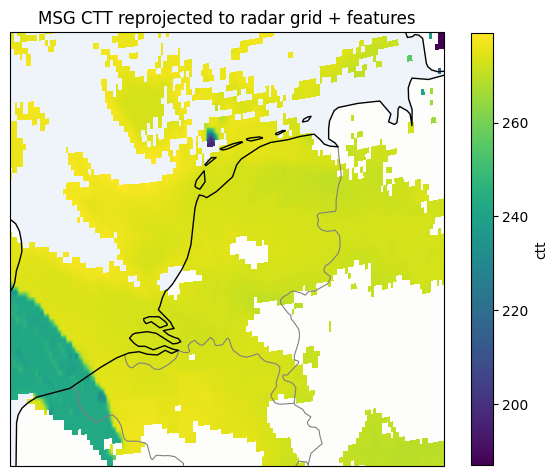

lon range: 1.4578854806804924 9.294411205256528
lat range: 49.9393665971178 54.71826665757862


In [71]:
da = da_msg_on_radar

crs_rad = CRS.from_wkt(da.rio.crs.to_wkt())
tf = Transformer.from_crs(crs_rad, CRS.from_epsg(4326), always_xy=True)

X, Y = np.meshgrid(da["x"].values, da["y"].values)   # (ny, nx) in metres
LON, LAT = tf.transform(X, Y)

Z = da.isel(time=0).values if "time" in da.dims else da.values

globe = ccrs.Globe(semimajor_axis=6378140, inverse_flattening=298.183263207106)
radar_crs = ccrs.Stereographic(
    central_longitude=0,
    central_latitude=90,
    true_scale_latitude=60,
    globe=globe,
)


fig = plt.figure(figsize=(7, 7))
ax = plt.axes(projection=radar_crs)

pm = ax.pcolormesh(
    da["x"].values, da["y"].values, Z,
    transform=radar_crs, shading="auto"
)
plt.colorbar(pm, ax=ax, shrink=0.8, label=(da.name or "value"))

ax.add_feature(cfeature.LAND.with_scale("50m"), alpha=0.10)
ax.add_feature(cfeature.OCEAN.with_scale("50m"), alpha=0.15)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), edgecolor="gray", linewidth=0.8)
ax.coastlines(resolution="50m", color="black", linewidth=1.0)

ax.set_extent([da["x"].values.min(), da["x"].values.max(),
               da["y"].values.min(), da["y"].values.max()],
              crs=radar_crs)

ax.set_title("MSG CTT reprojected to radar grid + features")
plt.show()


print("lon range:", float(np.nanmin(LON)), float(np.nanmax(LON)))
print("lat range:", float(np.nanmin(LAT)), float(np.nanmax(LAT)))

In [60]:
save=xr.DataArray(
    Z
)

In [61]:
from pyproj import CRS, Transformer

crs_msg = CRS.from_wkt(da_msg.rio.crs.to_wkt())
crs_rad = CRS.from_wkt(da_radar.isel(time=0).rio.crs.to_wkt())

tf_msg = Transformer.from_crs(crs_msg, CRS.from_epsg(4326), always_xy=True)
tf_rad = Transformer.from_crs(crs_rad, CRS.from_epsg(4326), always_xy=True)

def bounds_to_lonlat(bounds, tf):
    minx, miny, maxx, maxy = bounds
    corners = [(minx,miny),(maxx,miny),(maxx,maxy),(minx,maxy)]
    ll = [tf.transform(x,y) for x,y in corners]
    lons = [p[0] for p in ll]; lats = [p[1] for p in ll]
    return ll, (min(lons), min(lats), max(lons), max(lats))

ll_msg, bb_msg_ll = bounds_to_lonlat(da_msg.rio.bounds(), tf_msg)
ll_rad, bb_rad_ll = bounds_to_lonlat(da_radar.isel(time=0).rio.bounds(), tf_rad)

print("MSG corners lonlat:", ll_msg)
print("RAD corners lonlat:", ll_rad)
print("MSG lonlat bbox:", bb_msg_ll)
print("RAD lonlat bbox:", bb_rad_ll)


MSG corners lonlat: [(-12.915302219115947, 32.33659820830922), (29.017541392621403, 32.97025701006973), (inf, inf), (-29.138673516457537, 65.30429571319631)]
RAD corners lonlat: [(1.4510627638905587, 50.30243836614389), (8.212131694622023, 49.93454958873097), (9.302975186262655, 54.29512212975893), (1.646937980797975, 54.72276307282845)]
MSG lonlat bbox: (-29.138673516457537, 32.33659820830922, inf, inf)
RAD lonlat bbox: (1.4510627638905587, 49.93454958873097, 9.302975186262655, 54.72276307282845)
